<a href="https://colab.research.google.com/github/syedmahmoodiagents/MachineLearning/blob/main/AdaBoost_Regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [16]:
from sklearn.datasets import make_blobs

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
# X, y = make_regression(n_samples=500, n_features=1, noise=20)
X,_ = make_blobs(centers=5, cluster_std=1, random_state=1)

In [18]:
X.shape

(100, 2)

In [23]:
x = X[:,0]

In [24]:
xx = x.reshape(-1,1)

In [22]:
y = X[:,1]

In [31]:
np.ones(100) / 100

array([0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01])

In [37]:

w = np.ones(100) / 100

models = []
betas = []
n_estimators = 200

for t in range(n_estimators):

    model = DecisionTreeRegressor(max_depth=4)
    model.fit(xx, y, sample_weight=w)

    y_pred = model.predict(xx)

    error = np.abs(y - y_pred)

    max_error = error.max()

    if max_error == 0:
        break

    L = error / max_error

    # weighted error
    epsilon = np.sum(w * L)

    if epsilon >= 0.5:
        continue

    beta = epsilon / (1 - epsilon)

    w = w * (beta ** (1 - L))

    w = w / np.sum(w)

    models.append(model)
    betas.append(beta)



In [38]:
predictions = np.array([model.predict(xx) for model in models])

model_weights = np.log(1 / np.array(betas))

final_pred = []

for i in range(100):

    preds = predictions[:, i]

    sorted_idx = np.argsort(preds)

    preds = preds[sorted_idx]
    weights = model_weights[sorted_idx]

    cumulative = np.cumsum(weights)
    cutoff = cumulative[-1] / 2

    median_idx = np.where(cumulative >= cutoff)[0][0]

    final_pred.append(preds[median_idx])

preds = np.array(final_pred)

In [39]:
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score

In [40]:
import matplotlib.pyplot as plt

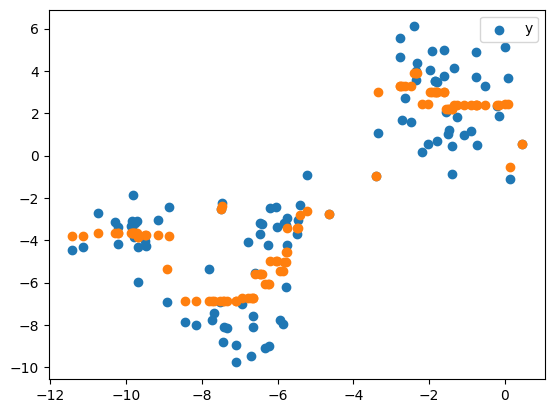

In [41]:
plt.scatter(x, y, label="y")
plt.scatter(x, preds)
plt.legend()

In [ ]:
x = np.linspace(2,8,51)

In [ ]:
fx = np.sin(x)

In [ ]:
np.random.seed(101)
y = fx + np.random.normal(0,0.6,51)

In [ ]:
Y = y.round(2)

In [ ]:
X = x.reshape(-1,1)

In [ ]:
X.shape

(51, 1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state=42)

model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=1),
    n_estimators=500,
    random_state=42,
    learning_rate=0.05
)

model.fit(X_train, y_train)


AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=1),
                  learning_rate=0.05, n_estimators=500, random_state=42)

In [ ]:
yp_train = model.predict(X_train)

In [ ]:
y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.37190383267991567
MSE: 0.32283548352993335


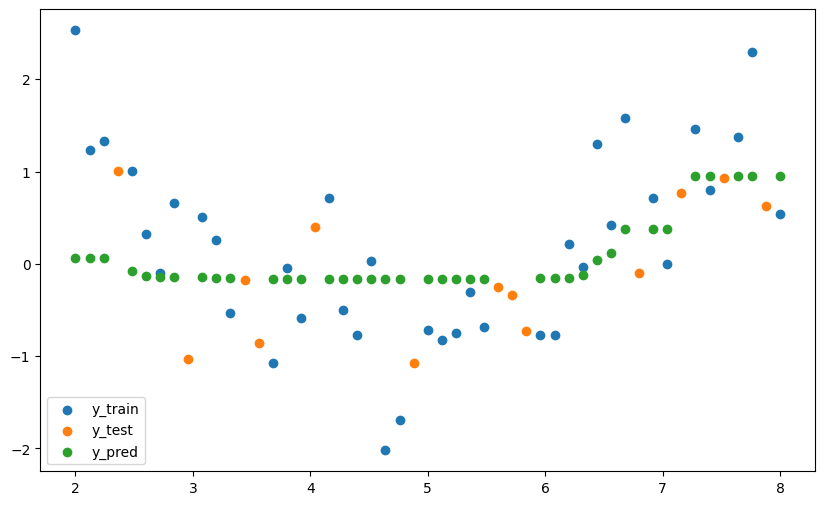

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X_train, y_train, label="y_train")
plt.scatter(X_test, y_test, label="y_test")
plt.scatter(X_train, yp_train, label="y_pred")
plt.legend()
